In [9]:
import cvxpy as cp
import math
import matplotlib.pyplot as plt
import numpy as np

In [29]:
m = 200
n = 100
A = np.random.randn(m, n)
b = np.random.randn(m)
b = b / (1.01 * np.max(np.abs(b)))

In [41]:
function_vec = [lambda x: cp.norm(x, 2), 
                lambda x: cp.norm(x, 1), 
                lambda x: cp.sum_largest(cp.abs(x), m//2),
                lambda x: cp.sum(cp.maximum(cp.abs(x) - 0.2, 0) + cp.maximum(cp.abs(x) - 0.3, 0)),
                lambda x: cp.sum(cp.huber(x, 0.2)),
                lambda x: cp.sum(-cp.log(1-x**2))]

num_functions = len(function_vec)
resid_vec = np.zeros((num_functions, m))
for i in range(num_functions):
    func = function_vec[i]
    # Define variables
    x = cp.Variable(n)
    # Define objective
    loss = func(A@x - b)
    objective = cp.Minimize(loss)
    # Define constraints
    constraints = []
    # Define problem
    problem = cp.Problem(objective, constraints)
    # Solve problem
    problem.solve()
    xval = x.value
    resid_vec[i, :] = A@xval - b
    # plt.hist(resid_vec[i])
    # plt.show()

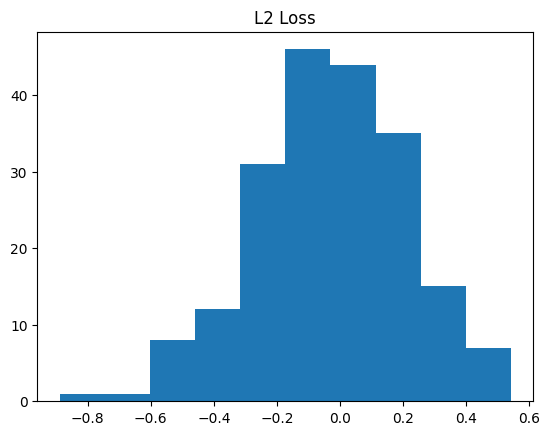

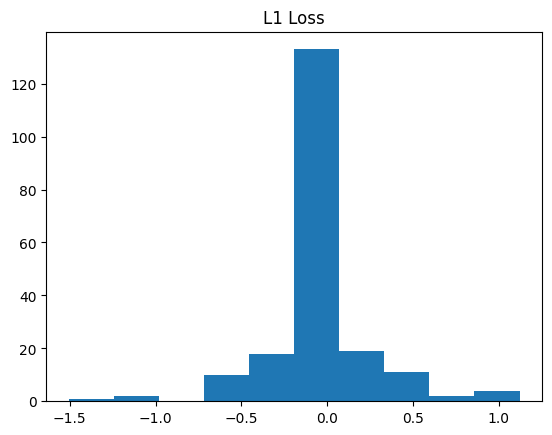

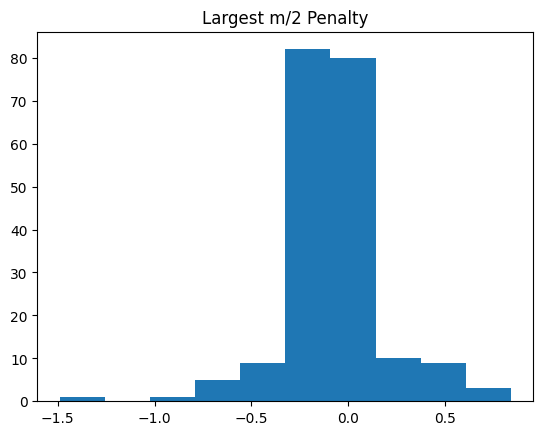

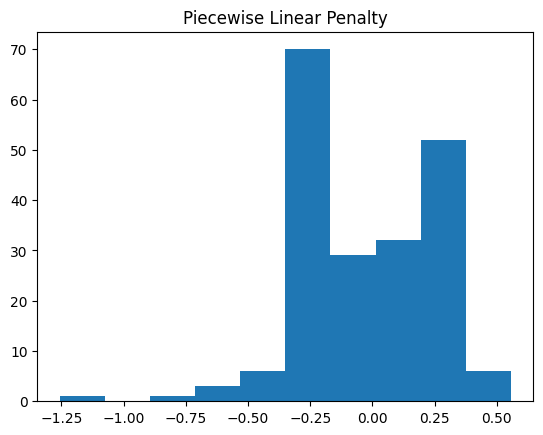

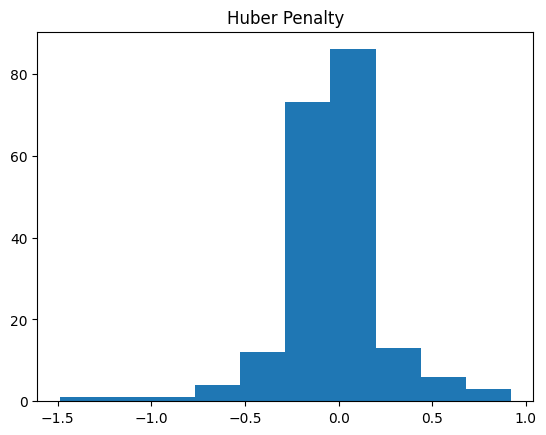

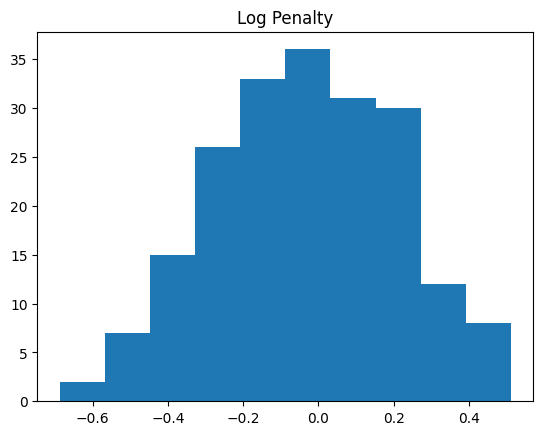

In [46]:
func_name = ["L2 Loss", "L1 Loss", "Largest m/2 Penalty", "Piecewise Linear Penalty", "Huber Penalty", "Log Penalty"]
for i in range(num_functions):
    plt.hist(resid_vec[i])
    plt.title(func_name[i])
    plt.show()